***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.4 自校准实战](9_4_self_calibration.ipynb)
    * 下一节： [9.6 时间平均、频率平均与展宽](9_6_averaging_and_smearing.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.5 图像质量评估与基本测量

当我们拿到一幅“看起来不错”的图像后，真正的工作并没有结束。至少还要回答下面这些问题：

- 背景噪声有多大？是否接近热噪声极限？
- 峰值与动态范围是多少？
- 某个源的总通量应该按 Jy/beam 还是 Jy 来理解？
- 扩展结构的积分测量是否考虑了 beam 面积？

这一节用一个合成 restored image 练习这些最基本、也最容易被忽视的测量动作。


***


In [2]:
from matplotlib.patches import Circle


def make_beam(npix=80, sigma_pix=2.0):
    coords = np.arange(npix) - npix // 2
    x, y = np.meshgrid(coords, coords)
    beam = np.exp(-(x**2 + y**2) / (2.0 * sigma_pix**2))
    beam /= beam.max()
    return beam


def fft_convolve_same(image, kernel):
    return np.real(np.fft.ifft2(np.fft.fft2(image) * np.fft.fft2(np.fft.ifftshift(kernel))))


def normalized_gaussian(l_grid, m_grid, l0, m0, sigma_l, sigma_m):
    profile = np.exp(
        -0.5 * (((l_grid - l0) / sigma_l) ** 2 + ((m_grid - m0) / sigma_m) ** 2)
    )
    profile /= profile.sum()
    return profile


def robust_rms(image, mask=None):
    if mask is None:
        values = image.ravel()
    else:
        values = image[mask]
    median = np.median(values)
    mad = np.median(np.abs(values - median))
    return 1.4826 * mad


npix = 80
cell = 0.8
coords = (np.arange(npix) - npix // 2) * cell
l_grid, m_grid = np.meshgrid(coords, coords)

sky = np.zeros((npix, npix))
core_idx = np.argmin(np.abs(coords - 0.0))
sky[core_idx, core_idx] += 0.85
sky += 0.42 * normalized_gaussian(l_grid, m_grid, 14.0, -9.0, 3.6, 2.2)
weak_x = np.argmin(np.abs(coords - 12.0))
weak_y = np.argmin(np.abs(coords - (-18.0)))
sky[weak_y, weak_x] += 0.18

beam = make_beam(npix=npix, sigma_pix=2.1)
restored = fft_convolve_same(sky, beam)
restored += 0.004 * RNG.normal(size=restored.shape)

source_mask = (np.abs(l_grid) < 6.0) & (np.abs(m_grid) < 6.0)
background_mask = ~(
    ((l_grid - 0.0) ** 2 + (m_grid - 0.0) ** 2 < 7.0**2)
    | ((l_grid - 14.0) ** 2 + (m_grid + 9.0) ** 2 < 9.0**2)
    | ((l_grid + 18.0) ** 2 + (m_grid - 12.0) ** 2 < 6.0**2)
)

beam_area_pix = beam.sum()
noise_rms = robust_rms(restored, mask=background_mask)
peak = restored.max()
dynamic_range = peak / noise_rms
integrated_core = restored[source_mask].sum() / beam_area_pix

extended_mask = ((l_grid - 14.0) ** 2 + (m_grid + 9.0) ** 2) < 9.0**2
integrated_extended = restored[extended_mask].sum() / beam_area_pix


### 9.5.1 先做最基本的 QA 量

这里我们先估计三类量：

- **noise RMS**：背景噪声量级；
- **peak brightness**：图像峰值（通常以 Jy/beam 表示）；
- **dynamic range**：峰值与背景噪声之比。

然后再进入源测量。这样做的好处是：你会先知道这幅图到底有多可靠，再去解释它的精细结构。


Background RMS = 0.0042 Jy/beam
Peak brightness = 0.8490 Jy/beam
Dynamic range = 203.0
Beam area = 27.71 pixel


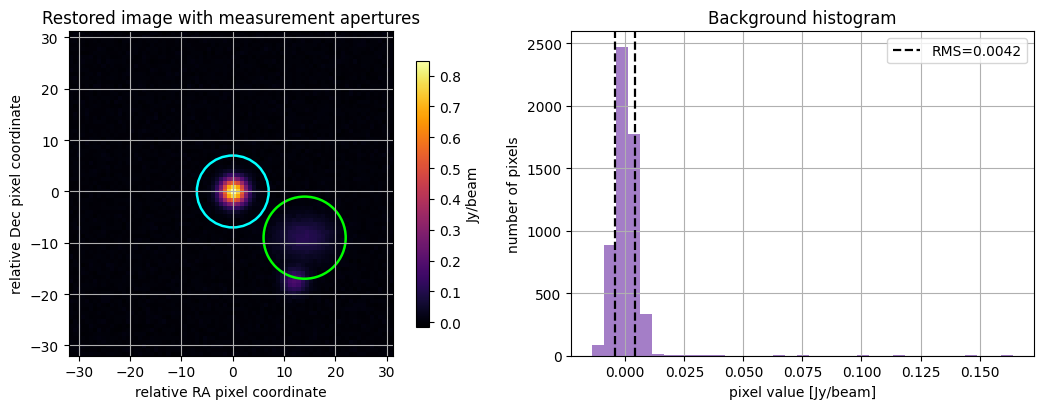

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

im = axes[0].imshow(
    restored,
    origin="lower",
    extent=[coords[0], coords[-1], coords[0], coords[-1]],
    cmap="inferno",
)
axes[0].add_patch(Circle((0.0, 0.0), radius=7.0, fill=False, ec="cyan", lw=1.8))
axes[0].add_patch(Circle((14.0, -9.0), radius=8.0, fill=False, ec="lime", lw=1.8))
axes[0].set_xlabel("relative RA pixel coordinate")
axes[0].set_ylabel("relative Dec pixel coordinate")
axes[0].set_title("Restored image with measurement apertures")
plt.colorbar(im, ax=axes[0], shrink=0.82, label="Jy/beam")

axes[1].hist(restored[background_mask].ravel(), bins=35, color="tab:purple", alpha=0.85)
axes[1].axvline(noise_rms, color="black", ls="--", lw=1.6, label=f"RMS={noise_rms:.4f}")
axes[1].axvline(-noise_rms, color="black", ls="--", lw=1.6)
axes[1].set_xlabel("pixel value [Jy/beam]")
axes[1].set_ylabel("number of pixels")
axes[1].set_title("Background histogram")
axes[1].legend(loc="upper right")

plt.tight_layout()
print(f"Background RMS = {noise_rms:.4f} Jy/beam")
print(f"Peak brightness = {peak:.4f} Jy/beam")
print(f"Dynamic range = {dynamic_range:.1f}")
print(f"Beam area = {beam_area_pix:.2f} pixel")


### 9.5.2 把 Jy/beam 正确转换成积分通量

一幅 restored image 常用的单位是 Jy/beam，因此如果你直接把一片区域内的像素值相加，得到的并不是 Jy，而是“Jy/beam 的像素和”。要得到积分通量，必须除以 beam 面积（以像素计）。


In [4]:
print(f"核心源积分通量（近似） = {integrated_core:.4f} Jy")
print(f"扩展源积分通量（近似） = {integrated_extended:.4f} Jy")


核心源积分通量（近似） = 0.8550 Jy
扩展源积分通量（近似） = 0.4921 Jy


### 9.5.3 一个最基本的图像 QA 清单

在进入科学解释之前，至少应完成下面这些检查：

- 背景是否近似零均值，噪声直方图是否近似对称；
- peak / RMS 是否达到预期动态范围；
- 负瓣或条纹 residual 是否主要围绕亮源出现；
- 对扩展源做积分通量时，是否已经正确考虑 beam 面积；
- 若后续要做源尺寸或形态测量，是否已经评估波束卷积的影响。
